# 09 — Temporal Model Challenge

## 这一步解决什么问题

前面的实验发现，模型在普通Validation上表现不错，但在2024年英国大选后的新政治环境中明显下降。这说明问题不只是“模型够不够复杂”，还包括历史规律会随时间失效。

本Notebook做一次最终Test之前的免费模型赛马：

1. `expanding_party_prior`：使用预测日期之前的全部历史，计算每个政党的支持率；
2. `rolling_12m_party_prior`：只使用最近12个月；
3. `rolling_24m_party_prior`：只使用最近24个月；
4. `rolling_100_party_prior`：每个政党只使用最近100条有效投票；
5. `structured_logistic`：读取政党角色、政府背书、议案类型和政策领域；
6. `time_decay_structured_logistic`：与上一个模型相同，但越新的历史权重越高；
7. `time_decay_text_logistic`：在时间衰减基础上加入TF-IDF议案文本；
8. `time_decay_xgboost`：若本机已有XGBoost，则比较保守参数的非线性树模型；否则自动使用sklearn的梯度提升作为免费替代。

这里不是随机切分。每次都只用某个时间点以前的数据预测后面的时期，模拟真实上线过程。

**安全边界：本Notebook只读取Train和Validation，不读取2025–2026 Test，不调用API，也不产生费用。**


## 为什么“最近100条投票”在这里可以测试

时间序列不一定要求每天都有数据。这里的一条观察是“某个政党对某个division的政策立场”。

Train中四个政党分别大约有663–769条有效记录，因此通常可以取得最近100条。不过早期回测或某个政党缺失较多时，实际数量可能不足。

代码采用两层保护：

- 每个回测时间点都会输出真实可用数量；
- 最近窗口少于30条时，自动退回该政党的全部既往历史，而不是用极小样本计算不稳定支持率。


In [1]:
# 导入免费时间回测需要的库；这里不会导入OpenAI，也不会调用任何API
import json
import math
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "processed" / "model_v2"
OUTPUT_DIR = BASE_DIR / "processed" / "temporal_model_challenge_v1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "model_train_v2.csv"
VALIDATION_PATH = DATA_DIR / "model_validation_v2.csv"

TARGET = "target_binary_support"
TEXT_COLUMN = "model_text"
RANDOM_STATE = 42
ELECTION_DATE = pd.Timestamp("2024-07-05")

# 这些参数在看回测结果之前固定，避免为了某一个时期反复调参
MIN_RECENT_VOTES = 30
ROLLING_VOTE_COUNT = 100
TIME_DECAY_HALF_LIFE_YEARS = 2.0
CLASSIFICATION_THRESHOLD = 0.50

# 候选模型必须稳定超过基准，而不是只在一个小窗口偶然获胜
MIN_MEAN_FOLD_IMPROVEMENT = 0.03
MIN_POST_ELECTION_IMPROVEMENT = 0.03
MIN_WORST_FOLD_MACRO_F1 = 0.50
MIN_WORST_PARTY_MACRO_F1 = 0.50

print("Notebook version: 09-temporal-model-challenge-v1")
print("API calls: 0")
print("LLM calls: 0")
print("Test loaded: False")
print("Output directory:", OUTPUT_DIR)


Notebook version: 09-temporal-model-challenge-v1
API calls: 0
LLM calls: 0
Test loaded: False
Output directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/temporal_model_challenge_v1


## 1. 读取开发数据，不接触最终Test

Train覆盖2016–2023；Validation覆盖2024。两者都属于模型开发数据，可以用于滚动回测和最终模型选择。

最终Test文件不会在本Notebook中定义路径，也不会被读取。


In [2]:
# 只读取Train和Validation，并统一日期、文本和标签格式
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALIDATION_PATH)

for frame in (train, validation):
    frame["motion_date"] = pd.to_datetime(frame["motion_date"])
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    frame[TEXT_COLUMN] = frame[TEXT_COLUMN].fillna("").astype(str)

# 同一个division不能同时出现在Train和Validation，否则会产生议案级泄漏
assert not set(train["division_key"]) & set(validation["division_key"])
assert train[TARGET].isin([0, 1]).all()
assert validation[TARGET].isin([0, 1]).all()

development = (
    pd.concat([train, validation], ignore_index=True)
    .sort_values(["motion_date", "division_key", "party"])
    .reset_index(drop=True)
)

development_overview = pd.DataFrame({
    "rows": [len(train), len(validation), len(development)],
    "divisions": [
        train["division_key"].nunique(),
        validation["division_key"].nunique(),
        development["division_key"].nunique(),
    ],
    "start_date": [
        train["motion_date"].min(),
        validation["motion_date"].min(),
        development["motion_date"].min(),
    ],
    "end_date": [
        train["motion_date"].max(),
        validation["motion_date"].max(),
        development["motion_date"].max(),
    ],
    "support_rate": [
        train[TARGET].mean(),
        validation[TARGET].mean(),
        development[TARGET].mean(),
    ],
}, index=["train", "validation", "development"])

display(development_overview.round(3))
display(
    development.groupby("party").agg(
        rows=("row_id", "size"),
        divisions=("division_key", "nunique"),
        support_rate=(TARGET, "mean"),
        first_vote=("motion_date", "min"),
        last_vote=("motion_date", "max"),
    ).round(3)
)


,rows,divisions,start_date,end_date,support_rate
train,2822,770,2016-01-06,2023-12-13,0.569
validation,570,169,2024-01-09,2024-12-17,0.591
development,3392,939,2016-01-06,2024-12-17,0.573


,rows,divisions,support_rate,first_vote,last_vote
party,,,,,
conservative,928,928,0.471,2016-01-06,2024-12-17
green,798,798,0.604,2016-01-06,2024-12-17
labour,851,851,0.602,2016-01-06,2024-12-17
liberal-democrat,815,815,0.628,2016-01-06,2024-12-17


## 2. 固定滚动回测时期

每个fold的训练数据必须严格早于该fold开始日期：

- 2021、2022、2023：检查长期稳定性；
- 2024大选前：检查原政治制度下的近期表现；
- 2024大选后早期：检查政府刚更替时的冷启动；
- 2024大选后晚期：允许模型使用早期大选后数据，检查它能否逐步适应。

这些日期不是根据模型分数选择的，而是由自然年份和政府更替日期预先确定。


In [3]:
# 使用左闭右开的时间区间，保证一条记录只进入一个评测fold
FOLDS = [
    {"fold": "2021", "start": "2021-01-01", "end": "2022-01-01", "era": "pre_election"},
    {"fold": "2022", "start": "2022-01-01", "end": "2023-01-01", "era": "pre_election"},
    {"fold": "2023", "start": "2023-01-01", "end": "2024-01-01", "era": "pre_election"},
    {"fold": "2024_pre", "start": "2024-01-01", "end": "2024-07-05", "era": "pre_election"},
    {"fold": "2024_early_post", "start": "2024-07-05", "end": "2024-11-06", "era": "post_election"},
    {"fold": "2024_late_post", "start": "2024-11-06", "end": "2025-01-01", "era": "post_election"},
]

for fold in FOLDS:
    fold["start"] = pd.Timestamp(fold["start"])
    fold["end"] = pd.Timestamp(fold["end"])

fold_rows = []
for fold in FOLDS:
    history = development[development["motion_date"] < fold["start"]]
    evaluation = development[
        (development["motion_date"] >= fold["start"])
        & (development["motion_date"] < fold["end"])
    ]
    fold_rows.append({
        "fold": fold["fold"],
        "era": fold["era"],
        "history_rows": len(history),
        "history_divisions": history["division_key"].nunique(),
        "evaluation_rows": len(evaluation),
        "evaluation_divisions": evaluation["division_key"].nunique(),
        "evaluation_parties": evaluation["party"].nunique(),
        "evaluation_support_rate": evaluation[TARGET].mean(),
    })

fold_overview = pd.DataFrame(fold_rows)
if (fold_overview["evaluation_rows"] == 0).any():
    raise ValueError("至少一个回测fold没有数据，请先检查日期范围。")

display(fold_overview.round(3))


,fold,era,history_rows,history_divisions,evaluation_rows,evaluation_divisions,evaluation_parties,evaluation_support_rate
0,2021,pre_election,1358,367,450,119,4,0.607
1,2022,pre_election,1808,486,500,140,4,0.566
2,2023,pre_election,2308,626,514,144,4,0.658
3,2024_pre,pre_election,2822,770,356,106,4,0.607
4,2024_early_post,post_election,3178,876,71,23,4,0.549
5,2024_late_post,post_election,3249,899,143,40,4,0.573


## 3. 检查每个政党到底有多少历史投票

这张表直接回答“有没有最近100条”的问题：

- `all_history_rows`：预测当时可使用的全部历史记录；
- `last_12m_rows`：最近12个月记录数；
- `last_24m_rows`：最近24个月记录数；
- `last_100_available`：最多能取到多少条，最大值为100；
- `12m_fallback`和`24m_fallback`：是否因为少于30条而回退到全部历史。


In [4]:
# 对每个fold和政党计算真实历史供应量，不假设每组一定有固定数量
availability_rows = []
parties = sorted(development["party"].unique())

for fold in FOLDS:
    history = development[development["motion_date"] < fold["start"]]
    for party in parties:
        party_history = history[history["party"] == party]
        last_12m = party_history[
            party_history["motion_date"] >= fold["start"] - pd.DateOffset(months=12)
        ]
        last_24m = party_history[
            party_history["motion_date"] >= fold["start"] - pd.DateOffset(months=24)
        ]
        availability_rows.append({
            "fold": fold["fold"],
            "party": party,
            "all_history_rows": len(party_history),
            "last_12m_rows": len(last_12m),
            "last_24m_rows": len(last_24m),
            "last_100_available": min(ROLLING_VOTE_COUNT, len(party_history)),
            "12m_fallback": len(last_12m) < MIN_RECENT_VOTES,
            "24m_fallback": len(last_24m) < MIN_RECENT_VOTES,
        })

recent_vote_availability = pd.DataFrame(availability_rows)
recent_vote_availability.to_csv(
    OUTPUT_DIR / "recent_vote_availability.csv", index=False
)
display(recent_vote_availability)


,fold,party,all_history_rows,last_12m_rows,last_24m_rows,last_100_available,12m_fallback,24m_fallback
0,2021,conservative,367,106,208,100,False,False
1,2021,green,318,80,173,100,False,False
2,2021,labour,341,87,188,100,False,False
3,2021,liberal-democrat,332,90,183,100,False,False
4,2022,conservative,486,119,225,100,False,False
5,2022,green,426,108,188,100,False,False
6,2022,labour,450,109,196,100,False,False
7,2022,liberal-democrat,446,114,204,100,False,False
8,2023,conservative,625,139,258,100,False,False
9,2023,green,537,111,219,100,False,False


## 4. 定义评价指标和动态Party Prior

Party Prior不是回归模型。它只是统计某个政党过去支持的比例。

这里加入`Beta(1,1)`平滑，相当于计算时额外放入一条支持和一条反对的虚拟记录。它不会明显改变几百条样本的结果，但能防止小窗口产生0%或100%的极端概率。

所有模型使用固定0.50阈值，不在每个fold单独寻找最佳阈值，避免偷偷针对未来时期调参。


In [5]:
def safe_roc_auc(y_true, probabilities):
    # 当一个小分组只有单一类别时，ROC-AUC没有定义
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)


def evaluate_probabilities(y_true, probabilities, threshold=0.50):
    # 同时保留分类正确性和概率质量，避免只看Accuracy
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = (probabilities >= threshold).astype(int)
    return {
        "rows": len(y_true),
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0),
        "support_precision": precision_score(y_true, predictions, zero_division=0),
        "support_recall": recall_score(y_true, predictions, zero_division=0),
        "roc_auc": safe_roc_auc(y_true, probabilities),
        "brier": brier_score_loss(y_true, probabilities),
    }


def smoothed_rate(frame):
    # Beta(1,1)平滑避免小样本出现绝对的0或1概率
    return (frame[TARGET].sum() + 1.0) / (len(frame) + 2.0)


def party_rate_map(history, selected_history=None):
    # 最近窗口不足时，逐个政党回退到该政党的全部既往历史
    global_rate = smoothed_rate(history)
    rates = {}
    for party in parties:
        full_party = history[history["party"] == party]
        recent_party = (
            selected_history[selected_history["party"] == party]
            if selected_history is not None
            else full_party
        )
        source = recent_party if len(recent_party) >= MIN_RECENT_VOTES else full_party
        rates[party] = smoothed_rate(source) if len(source) else global_rate
    return rates


def prior_probabilities(history, evaluation, mode, fold_start):
    # 根据预先定义的窗口生成每个政党的动态支持概率
    if mode == "expanding":
        selected = None
    elif mode == "12m":
        selected = history[
            history["motion_date"] >= fold_start - pd.DateOffset(months=12)
        ]
    elif mode == "24m":
        selected = history[
            history["motion_date"] >= fold_start - pd.DateOffset(months=24)
        ]
    elif mode == "last_100":
        selected = (
            history.sort_values("motion_date")
            .groupby("party", group_keys=False)
            .tail(ROLLING_VOTE_COUNT)
        )
    else:
        raise ValueError(f"未知Party Prior模式：{mode}")

    rates = party_rate_map(history, selected)
    return evaluation["party"].map(rates).astype(float).to_numpy()


## 5. 定义模型可使用的字段

只使用投票发生前能够知道的信息：

- 政党及其当时的制度角色；
- 政策对象是否由政府背书；
- motion type、motion family和政策领域；
- 月份及少量议会程序特征；
- 议案文本，仅供TF-IDF版本使用。

不会使用当前投票结果、赞成票数、反对票数或任何目标衍生字段。


In [6]:
# 类别字段表达政治身份、制度角色和议案语境
CATEGORICAL_FEATURES = [
    "party",
    "party_role",
    "government_party",
    "main_opposition_party",
    "final_object_government_backed",
    "government_backing_known",
    "motion_type",
    "motion_family",
    "policy_domain_primary",
]

# 数值字段全部在投票前可以获得，不包含任何投票结果
NUMERIC_FEATURES = [
    "motion_month",
    "total_possible_members",
    "is_governing_party",
    "is_main_opposition",
    "is_opposition_day",
    "is_amendment",
    "is_new_clause",
    "is_financial_motion",
    "policy_domain_count",
]

FORBIDDEN_FEATURES = {
    TARGET,
    "party_result",
    "party_for",
    "party_against",
    "party_for_percentage",
    "party_majority",
    "party_absent",
    "total_for",
    "total_against",
    "total_result",
    "total_majority",
    "target_policy_result",
    "target_policy_stance",
    "target_policy_stance_score",
    "target_ordinal_provisional",
}

selected_features = set(CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TEXT_COLUMN])
assert not selected_features & FORBIDDEN_FEATURES
missing_features = selected_features - set(development.columns)
assert not missing_features, f"缺少模型字段：{sorted(missing_features)}"

# 显式转换数值列，无法解析的值交给中位数补缺
for column in NUMERIC_FEATURES:
    development[column] = pd.to_numeric(development[column], errors="coerce")

# 统一类别类型，避免布尔值、字符串和缺失值混合导致编码器报错
for column in CATEGORICAL_FEATURES:
    development[column] = development[column].fillna("__missing__").astype(str)

print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Numeric features:", len(NUMERIC_FEATURES))
print("Text feature:", TEXT_COLUMN)


Categorical features: 9
Numeric features: 9
Text feature: model_text


## 6. 为什么使用两年半衰期

时间权重使用下式：

```text
weight = 0.5 ** (历史年龄 / 2年)
```

因此：

- 刚发生的投票权重接近1；
- 两年前的投票权重为0.5；
- 四年前为0.25；
- 六年前为0.125。

这样不会直接删除旧数据，也不会让2016年的投票与2024年的投票同等重要。两年是预先固定的折中值，本Notebook不搜索几十种半衰期。


In [7]:
def time_decay_weights(history, reference_date):
    # 用预测窗口开始日期计算历史年龄，越新的记录权重越高
    age_days = (reference_date - history["motion_date"]).dt.days.clip(lower=0)
    age_years = age_days / 365.25
    return np.power(0.5, age_years / TIME_DECAY_HALF_LIFE_YEARS)


def make_structured_preprocessor():
    # 类别字段独热编码；数值字段补中位数后缩放
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ], remainder="drop")


def make_structured_logistic():
    # C=0.5提供较强正则化，降低小数据过拟合风险
    return Pipeline([
        ("features", make_structured_preprocessor()),
        ("model", LogisticRegression(
            C=0.5,
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ])


def make_text_logistic():
    # TF-IDF自动从历史文本学习一词和二词组合，不需要人工指定关键词
    text_and_structured = ColumnTransformer([
        ("text", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.98,
            max_features=20000,
            sublinear_tf=True,
        ), TEXT_COLUMN),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_FEATURES),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler(with_mean=False)),
        ]), NUMERIC_FEATURES),
    ], remainder="drop")

    return Pipeline([
        ("features", text_and_structured),
        ("model", LogisticRegression(
            C=0.5,
            max_iter=3000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ])


def positive_probabilities(model, frame):
    # 明确寻找类别1所在列，避免假设predict_proba列顺序
    positive_index = list(model.named_steps["model"].classes_).index(1)
    return model.predict_proba(frame)[:, positive_index]


## 7. XGBoost参数为什么这样设置

若环境已有`xgboost`，使用以下保守配置：

- `max_depth=3`：树保持浅层，避免记住少量议案；
- `learning_rate=0.03`：每棵树只做小幅修正；
- `n_estimators=300`：配合较低学习率逐步学习；
- `min_child_weight=10`：太少样本的分支不继续切分；
- `subsample=0.8`和`colsample_bytree=0.8`：每棵树只看部分样本和字段，降低过拟合；
- `reg_lambda=5`：加强L2正则化。

如果没有安装XGBoost，代码不会报错或要求付费下载，而是使用sklearn自带的`HistGradientBoostingClassifier`完成同类非线性检查。

树模型只使用结构字段，不直接吃20,000维TF-IDF，因为小样本中的高维稀疏文本更适合正则化Logistic Regression。


In [8]:
# 检查本地是否已经安装XGBoost；没有时使用sklearn免费替代
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False


def fit_tree_candidate(history, evaluation, sample_weights):
    # 先把类别与数值字段转换成树模型可以读取的矩阵
    preprocessor = make_structured_preprocessor()
    train_matrix = preprocessor.fit_transform(history)
    evaluation_matrix = preprocessor.transform(evaluation)

    if XGBOOST_AVAILABLE:
        model_name = "time_decay_xgboost"
        model = XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=5.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(train_matrix, history[TARGET], sample_weight=sample_weights)
        probabilities = model.predict_proba(evaluation_matrix)[:, 1]
    else:
        model_name = "time_decay_hist_gradient_boosting"
        model = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=5.0,
            random_state=RANDOM_STATE,
        )
        dense_train = (
            train_matrix.toarray()
            if hasattr(train_matrix, "toarray")
            else np.asarray(train_matrix)
        )
        dense_evaluation = (
            evaluation_matrix.toarray()
            if hasattr(evaluation_matrix, "toarray")
            else np.asarray(evaluation_matrix)
        )
        model.fit(
            dense_train,
            history[TARGET],
            sample_weight=sample_weights,
        )
        probabilities = model.predict_proba(dense_evaluation)[:, 1]

    return model_name, probabilities


print("XGBoost available:", XGBOOST_AVAILABLE)


XGBoost available: True


## 8. 执行严格的walk-forward回测

每个fold都会重新训练模型，并且训练集只包含该fold开始日期之前的记录。

例如预测`2024_early_post`时，模型看不到任何2024年7月5日之后的标签；预测`2024_late_post`时，才允许使用大选后早期已经发生的投票。


In [9]:
# 保存每一行、每一个模型的概率，便于之后定位问题而不是只看总分
prediction_parts = []
fit_time_rows = []


def append_predictions(evaluation, fold, model_name, probabilities):
    # 统一成长表，保证所有模型使用完全相同的评测行
    part = evaluation[[
        "row_id",
        "division_key",
        "motion_date",
        "party",
        "motion_title_clean",
        "motion_family",
        "policy_domain_primary",
        TARGET,
    ]].copy()
    part["fold"] = fold["fold"]
    part["era"] = fold["era"]
    part["model"] = model_name
    part["probability"] = np.asarray(probabilities, dtype=float)
    part["prediction"] = (
        part["probability"] >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    prediction_parts.append(part)


for fold in FOLDS:
    print(f"Running fold: {fold['fold']}")
    history = development[
        development["motion_date"] < fold["start"]
    ].copy()
    evaluation = development[
        (development["motion_date"] >= fold["start"])
        & (development["motion_date"] < fold["end"])
    ].copy()

    # 同一个division不允许同时落入历史和当前评测窗口
    assert not set(history["division_key"]) & set(evaluation["division_key"])

    prior_modes = {
        "expanding_party_prior": "expanding",
        "rolling_12m_party_prior": "12m",
        "rolling_24m_party_prior": "24m",
        "rolling_100_party_prior": "last_100",
    }
    for model_name, mode in prior_modes.items():
        started = time.perf_counter()
        probabilities = prior_probabilities(
            history, evaluation, mode, fold["start"]
        )
        fit_time_rows.append({
            "fold": fold["fold"],
            "model": model_name,
            "fit_seconds": time.perf_counter() - started,
        })
        append_predictions(evaluation, fold, model_name, probabilities)

    # 普通结构化Logistic让全部历史拥有相同权重
    started = time.perf_counter()
    structured_model = make_structured_logistic()
    structured_model.fit(history, history[TARGET])
    probabilities = positive_probabilities(structured_model, evaluation)
    fit_time_rows.append({
        "fold": fold["fold"],
        "model": "structured_logistic",
        "fit_seconds": time.perf_counter() - started,
    })
    append_predictions(
        evaluation, fold, "structured_logistic", probabilities
    )

    # 时间衰减结构化Logistic降低过旧投票的影响
    sample_weights = time_decay_weights(history, fold["start"])
    started = time.perf_counter()
    decay_structured_model = make_structured_logistic()
    decay_structured_model.fit(
        history,
        history[TARGET],
        model__sample_weight=sample_weights,
    )
    probabilities = positive_probabilities(decay_structured_model, evaluation)
    fit_time_rows.append({
        "fold": fold["fold"],
        "model": "time_decay_structured_logistic",
        "fit_seconds": time.perf_counter() - started,
    })
    append_predictions(
        evaluation,
        fold,
        "time_decay_structured_logistic",
        probabilities,
    )

    # 时间衰减文本Logistic同时读取TF-IDF文本和制度字段
    started = time.perf_counter()
    decay_text_model = make_text_logistic()
    decay_text_model.fit(
        history,
        history[TARGET],
        model__sample_weight=sample_weights,
    )
    probabilities = positive_probabilities(decay_text_model, evaluation)
    fit_time_rows.append({
        "fold": fold["fold"],
        "model": "time_decay_text_logistic",
        "fit_seconds": time.perf_counter() - started,
    })
    append_predictions(
        evaluation, fold, "time_decay_text_logistic", probabilities
    )

    # 非线性树模型读取同一套结构字段，并使用相同时间权重
    started = time.perf_counter()
    tree_model_name, probabilities = fit_tree_candidate(
        history, evaluation, sample_weights
    )
    fit_time_rows.append({
        "fold": fold["fold"],
        "model": tree_model_name,
        "fit_seconds": time.perf_counter() - started,
    })
    append_predictions(evaluation, fold, tree_model_name, probabilities)

predictions = pd.concat(prediction_parts, ignore_index=True)
fit_times = pd.DataFrame(fit_time_rows)

predictions.to_csv(
    OUTPUT_DIR / "temporal_model_predictions.csv", index=False
)
fit_times.to_csv(OUTPUT_DIR / "temporal_model_fit_times.csv", index=False)

print("Prediction rows:", len(predictions))
print("Models:", sorted(predictions["model"].unique()))


Running fold: 2021
Running fold: 2022
Running fold: 2023
Running fold: 2024_pre
Running fold: 2024_early_post
Running fold: 2024_late_post
Prediction rows: 16272
Models: ['expanding_party_prior', 'rolling_100_party_prior', 'rolling_12m_party_prior', 'rolling_24m_party_prior', 'structured_logistic', 'time_decay_structured_logistic', 'time_decay_text_logistic', 'time_decay_xgboost']


## 9. 分别检查整体、时间窗口和政党表现

模型选择的主指标是各fold Macro-F1的简单平均，而不是把所有年份混在一起算一个大分数。这样数据较多的年份不会掩盖2024年政府更替后的失败。

同时保留：

- `worst_fold_macro_f1`：模型最差时间窗口；
- `post_election_macro_f1`：2024大选后的表现；
- `worst_party_macro_f1`：表现最差的政党；
- `brier`：预测概率与真实结果之间的误差，越低越好。


In [10]:
def grouped_metrics(frame, group_columns):
    # 对任意模型、时期或政党分组重复计算同一套指标
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        record = dict(zip(group_columns, keys))
        record.update(evaluate_probabilities(
            group[TARGET],
            group["probability"],
            CLASSIFICATION_THRESHOLD,
        ))
        rows.append(record)
    return pd.DataFrame(rows)


aggregate_metrics = grouped_metrics(predictions, ["model"])
fold_metrics = grouped_metrics(predictions, ["model", "fold", "era"])
party_metrics = grouped_metrics(predictions, ["model", "party"])

fold_summary = fold_metrics.groupby("model").agg(
    mean_fold_macro_f1=("macro_f1", "mean"),
    worst_fold_macro_f1=("macro_f1", "min"),
).reset_index()

post_summary = (
    grouped_metrics(
        predictions[predictions["era"] == "post_election"],
        ["model"],
    )
    .rename(columns={
        "macro_f1": "post_election_macro_f1",
        "accuracy": "post_election_accuracy",
        "roc_auc": "post_election_roc_auc",
    })[[
        "model",
        "post_election_macro_f1",
        "post_election_accuracy",
        "post_election_roc_auc",
    ]]
)

worst_party = party_metrics.groupby("model")["macro_f1"].min().reset_index(
    name="worst_party_macro_f1"
)

model_comparison = (
    aggregate_metrics
    .merge(fold_summary, on="model", how="left")
    .merge(post_summary, on="model", how="left")
    .merge(worst_party, on="model", how="left")
    .merge(
        fit_times.groupby("model", as_index=False)["fit_seconds"].sum(),
        on="model",
        how="left",
    )
    .sort_values(
        ["mean_fold_macro_f1", "post_election_macro_f1"],
        ascending=False,
    )
    .reset_index(drop=True)
)

model_comparison.to_csv(
    OUTPUT_DIR / "temporal_model_comparison.csv", index=False
)
fold_metrics.to_csv(OUTPUT_DIR / "temporal_fold_metrics.csv", index=False)
party_metrics.to_csv(OUTPUT_DIR / "temporal_party_metrics.csv", index=False)

display(model_comparison.round(3))
display(
    fold_metrics.pivot(
        index="model", columns="fold", values="macro_f1"
    ).round(3)
)
display(
    party_metrics.pivot(
        index="model", columns="party", values="macro_f1"
    ).round(3)
)


,model,rows,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,roc_auc,brier,mean_fold_macro_f1,worst_fold_macro_f1,post_election_macro_f1,post_election_accuracy,post_election_roc_auc,worst_party_macro_f1,fit_seconds
0,time_decay_xgboost,2034,0.802,0.795,0.794,0.841,0.830,0.886,0.134,0.718,0.421,0.532,0.533,0.515,0.753,1.235
1,rolling_100_party_prior,2034,0.663,0.621,0.622,0.685,0.820,0.628,0.225,0.609,0.517,0.591,0.631,0.625,0.377,0.015
2,rolling_12m_party_prior,2034,0.663,0.621,0.622,0.685,0.820,0.602,0.228,0.609,0.517,0.591,0.631,0.577,0.377,0.012
3,structured_logistic,2034,0.655,0.620,0.622,0.688,0.787,0.648,0.226,0.585,0.401,0.443,0.453,0.428,0.248,0.075
4,time_decay_structured_logistic,2034,0.645,0.608,0.609,0.679,0.785,0.704,0.219,0.584,0.426,0.473,0.495,0.495,0.233,0.069
5,time_decay_text_logistic,2034,0.647,0.609,0.610,0.679,0.790,0.716,0.216,0.580,0.413,0.460,0.491,0.502,0.226,1.342
6,rolling_24m_party_prior,2034,0.613,0.579,0.579,0.661,0.738,0.597,0.231,0.578,0.418,0.591,0.631,0.620,0.412,0.013
7,expanding_party_prior,2034,0.588,0.522,0.499,0.618,0.833,0.560,0.240,0.497,0.361,0.591,0.631,0.586,0.412,0.008


fold,2021,2022,2023,2024_early_post,2024_late_post,2024_pre
model,,,,,,
expanding_party_prior,0.418,0.361,0.397,0.517,0.627,0.661
rolling_100_party_prior,0.607,0.551,0.691,0.517,0.627,0.661
rolling_12m_party_prior,0.607,0.551,0.691,0.517,0.627,0.661
rolling_24m_party_prior,0.418,0.551,0.691,0.517,0.627,0.661
structured_logistic,0.642,0.623,0.628,0.522,0.401,0.691
time_decay_structured_logistic,0.603,0.586,0.629,0.570,0.426,0.691
time_decay_text_logistic,0.596,0.606,0.642,0.556,0.413,0.667
time_decay_xgboost,0.772,0.811,0.861,0.421,0.583,0.860


party,conservative,green,labour,liberal-democrat
model,,,,
expanding_party_prior,0.469,0.507,0.471,0.412
rolling_100_party_prior,0.377,0.404,0.404,0.412
rolling_12m_party_prior,0.377,0.404,0.404,0.412
rolling_24m_party_prior,0.488,0.507,0.471,0.412
structured_logistic,0.248,0.782,0.739,0.810
time_decay_structured_logistic,0.233,0.763,0.721,0.796
time_decay_text_logistic,0.226,0.776,0.727,0.793
time_decay_xgboost,0.806,0.753,0.769,0.765


## 10. 用预先固定的门槛决定是否替换Party Prior

不会因为某个复杂模型比Party Prior高0.001就采用它。最好的挑战者必须同时满足：

- 平均fold Macro-F1至少高0.03；
- 大选后Macro-F1至少高0.03；
- 最差fold Macro-F1至少0.50；
- 最差政党Macro-F1至少0.50。

如果没有模型通过，结论不是“Party Prior是高级模型”，而是“现有复杂模型还没有提供可靠的增量价值”。


In [11]:
BASELINE_MODEL = "expanding_party_prior"
baseline = model_comparison.set_index("model").loc[BASELINE_MODEL]

challengers = model_comparison[
    model_comparison["model"] != BASELINE_MODEL
].copy()
challengers = challengers.sort_values(
    [
        "mean_fold_macro_f1",
        "post_election_macro_f1",
        "worst_party_macro_f1",
    ],
    ascending=False,
)
selected_challenger = challengers.iloc[0]

acceptance_gates = {
    "mean_fold_improvement_gate": bool(
        selected_challenger["mean_fold_macro_f1"]
        >= baseline["mean_fold_macro_f1"] + MIN_MEAN_FOLD_IMPROVEMENT
    ),
    "post_election_improvement_gate": bool(
        selected_challenger["post_election_macro_f1"]
        >= baseline["post_election_macro_f1"]
        + MIN_POST_ELECTION_IMPROVEMENT
    ),
    "worst_fold_gate": bool(
        selected_challenger["worst_fold_macro_f1"]
        >= MIN_WORST_FOLD_MACRO_F1
    ),
    "worst_party_gate": bool(
        selected_challenger["worst_party_macro_f1"]
        >= MIN_WORST_PARTY_MACRO_F1
    ),
}

challenger_passes = all(acceptance_gates.values())
recommended_model = (
    selected_challenger["model"]
    if challenger_passes
    else BASELINE_MODEL
)

recommendation = {
    "notebook_version": "09-temporal-model-challenge-v1",
    "selected_challenger": str(selected_challenger["model"]),
    "challenger_passes": bool(challenger_passes),
    "recommended_model": str(recommended_model),
    "classification_threshold": float(CLASSIFICATION_THRESHOLD),
    "time_decay_half_life_years": float(TIME_DECAY_HALF_LIFE_YEARS),
    "acceptance_gates": acceptance_gates,
    "test_loaded": False,
    "api_calls": 0,
}

with (OUTPUT_DIR / "model_freeze_recommendation.json").open(
    "w", encoding="utf-8"
) as handle:
    json.dump(recommendation, handle, ensure_ascii=False, indent=2)

print("Selected challenger:", selected_challenger["model"])
print("Acceptance gates:", acceptance_gates)
print("Recommended model:", recommended_model)


Selected challenger: time_decay_xgboost
Acceptance gates: {'mean_fold_improvement_gate': True, 'post_election_improvement_gate': False, 'worst_fold_gate': False, 'worst_party_gate': True}
Recommended model: expanding_party_prior


## 11. 可视化时间稳定性

第一张图比较每个模型在不同时期的Macro-F1；第二张图比较整体与大选后表现。重点观察曲线是否在2024年大选后突然坠落。


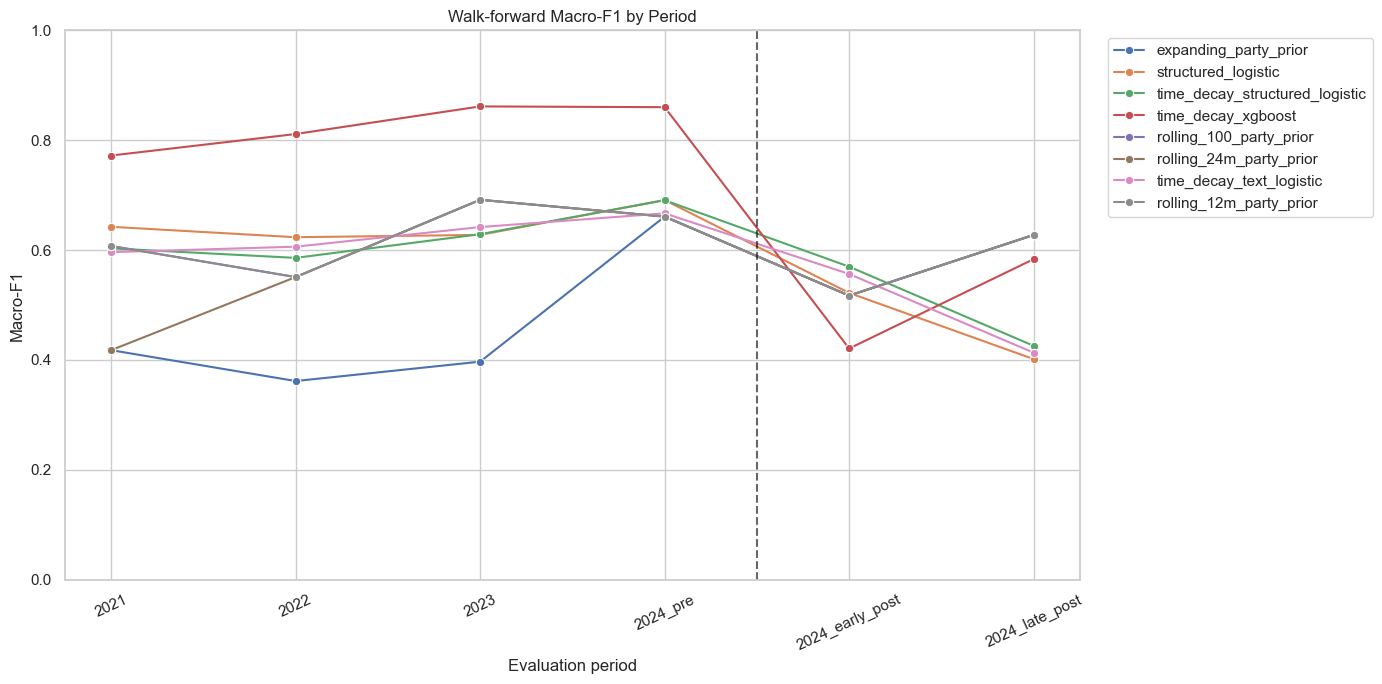

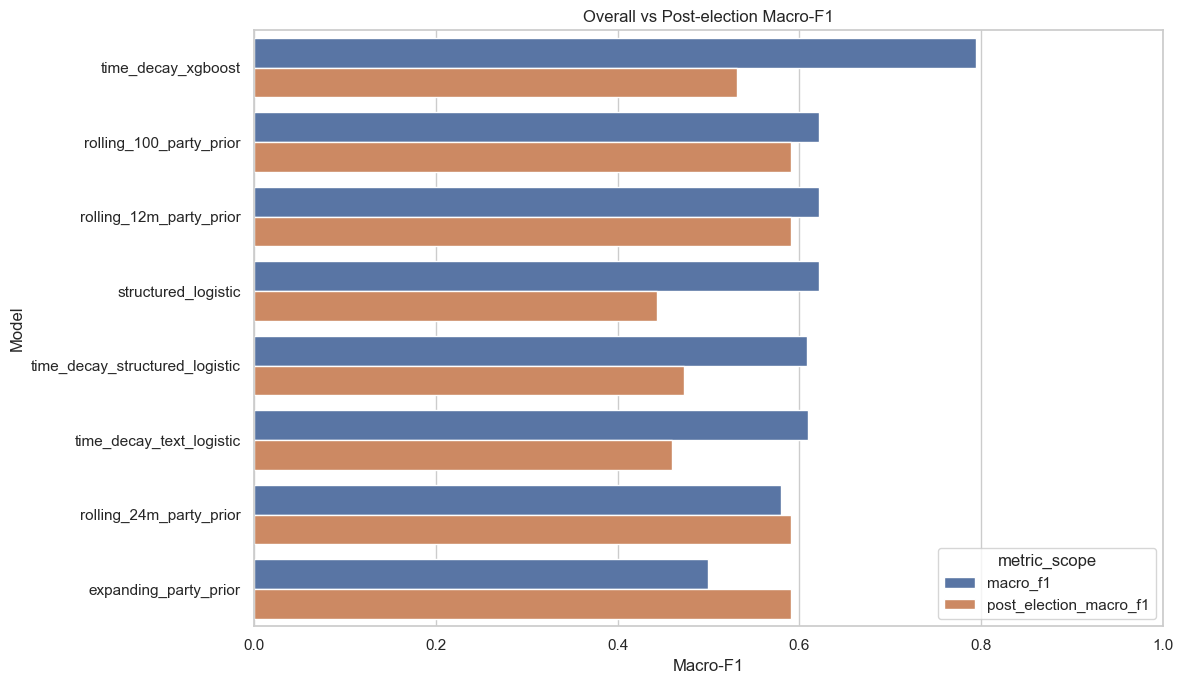

In [13]:
# 画出每个模型随时间变化的Macro-F1
fold_order = [fold["fold"] for fold in FOLDS]
plot_frame = fold_metrics.copy()
plot_frame["fold"] = pd.Categorical(
    plot_frame["fold"], categories=fold_order, ordered=True
)

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=plot_frame.sort_values("fold"),
    x="fold",
    y="macro_f1",
    hue="model",
    marker="o",
)
plt.axvline(3.5, color="black", linestyle="--", alpha=0.6)
plt.ylim(0, 1)
plt.title("Walk-forward Macro-F1 by Period")
plt.xlabel("Evaluation period")
plt.ylabel("Macro-F1")
plt.xticks(rotation=25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "walk_forward_macro_f1.png", dpi=160)
plt.show()

comparison_plot = model_comparison[[
    "model", "macro_f1", "post_election_macro_f1"
]].melt(
    id_vars="model",
    var_name="metric_scope",
    value_name="metric_value",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=comparison_plot,
    y="model",
    x="metric_value",
    hue="metric_scope",
)
plt.xlim(0, 1)
plt.title("Overall vs Post-election Macro-F1")
plt.xlabel("Macro-F1")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overall_vs_post_election.png", dpi=160)
plt.show()


## 12. 输出供下一步审阅的摘要

请把最后这个文本框完整复制回来。我们将根据真实结果决定：

- 冻结时间模型并准备最终Test；或
- 保留Party Prior作为诚实基准，并把RAG限定为证据解释层。

不要在看到这份结果之前运行最终Test。


In [14]:
baseline_row = model_comparison.set_index("model").loc[BASELINE_MODEL]
challenger_row = model_comparison.set_index("model").loc[
    selected_challenger["model"]
]

summary_lines = [
    "=== TEMPORAL MODEL CHALLENGE SUMMARY FOR REVIEW ===",
    "Notebook version: 09-temporal-model-challenge-v1",
    "API calls: 0",
    "LLM calls: 0",
    "Test loaded: False",
    f"Development rows: {len(development)}",
    f"Development divisions: {development['division_key'].nunique()}",
    f"Walk-forward folds: {len(FOLDS)}",
    f"XGBoost available: {XGBOOST_AVAILABLE}",
    f"Minimum historical rows per party across folds: "
    f"{int(recent_vote_availability['all_history_rows'].min())}",
    f"Minimum recent-100 availability: "
    f"{int(recent_vote_availability['last_100_available'].min())}",
    f"Selected challenger: {selected_challenger['model']}",
    f"Challenger mean-fold Macro-F1: "
    f"{challenger_row['mean_fold_macro_f1']:.3f}",
    f"Challenger post-election Macro-F1: "
    f"{challenger_row['post_election_macro_f1']:.3f}",
    f"Challenger worst-fold Macro-F1: "
    f"{challenger_row['worst_fold_macro_f1']:.3f}",
    f"Challenger worst-party Macro-F1: "
    f"{challenger_row['worst_party_macro_f1']:.3f}",
    f"Expanding Party Prior mean-fold Macro-F1: "
    f"{baseline_row['mean_fold_macro_f1']:.3f}",
    f"Expanding Party Prior post-election Macro-F1: "
    f"{baseline_row['post_election_macro_f1']:.3f}",
    f"Acceptance gates: {acceptance_gates}",
    f"Challenger passes: {challenger_passes}",
    f"Recommended model: {recommended_model}",
    "Model comparison:",
    model_comparison[[
        "model",
        "mean_fold_macro_f1",
        "worst_fold_macro_f1",
        "post_election_macro_f1",
        "worst_party_macro_f1",
        "macro_f1",
        "accuracy",
        "roc_auc",
        "brier",
        "fit_seconds",
    ]].round(3).to_string(index=False),
    "RUN_FINAL_TEST: False",
    "Test result: NOT RUN",
    f"Output directory: {OUTPUT_DIR}",
    "=== END TEMPORAL MODEL CHALLENGE SUMMARY ===",
]

summary_text = "\n".join(summary_lines)
print(summary_text)
(OUTPUT_DIR / "temporal_model_challenge_summary.txt").write_text(
    summary_text, encoding="utf-8"
)


=== TEMPORAL MODEL CHALLENGE SUMMARY FOR REVIEW ===
Notebook version: 09-temporal-model-challenge-v1
API calls: 0
LLM calls: 0
Test loaded: False
Development rows: 3392
Development divisions: 939
Walk-forward folds: 6
XGBoost available: True
Minimum historical rows per party across folds: 318
Minimum recent-100 availability: 100
Selected challenger: time_decay_xgboost
Challenger mean-fold Macro-F1: 0.718
Challenger post-election Macro-F1: 0.532
Challenger worst-fold Macro-F1: 0.421
Challenger worst-party Macro-F1: 0.753
Expanding Party Prior mean-fold Macro-F1: 0.497
Expanding Party Prior post-election Macro-F1: 0.591
Acceptance gates: {'mean_fold_improvement_gate': True, 'post_election_improvement_gate': False, 'worst_fold_gate': False, 'worst_party_gate': True}
Challenger passes: False
Recommended model: expanding_party_prior
Model comparison:
                         model  mean_fold_macro_f1  worst_fold_macro_f1  post_election_macro_f1  worst_party_macro_f1  macro_f1  accuracy  roc

2554